# Sentinel-2 ACOLITE validation of Sangatta turbidity

The same-day Sentinel-2C/ACOLITE result supports the Tanager plume in scale and spatial pattern.
Across 170,007 common valid 30 m water pixels, Tanager and Sentinel-2 have similar p95 turbidity
(**19.52 vs 19.32 FNU**) and a Spearman rho of **0.854**. Sentinel-2 has a lower clear-water
median (**2.47 vs 3.19 FNU**), while **94.6%** of paired pixels are within a factor of two.

The Tanager distribution is strongly skewed. Only **7 pixels (0.0034%) exceed 500 FNU**, while
the 95th percentile is 23.65 FNU. **5.50% (11,489/208,720) of valid, unsaturated water
pixels use mostly NIR.**

Sources: Tanager scene `20250302_030003_92_4001`; Sentinel-2C product
`S2C_MSIL1C_20250302T021641_N0511_R003_T50NNF_20250302T055307`; ACOLITE 20260421.0;
Dogliotti et al. (2015).


## Context and methods

This notebook validates the FNU scale from [`04_quantitative_turbidity.ipynb`](./04_quantitative_turbidity.ipynb)
with an independent, nearly simultaneous sensor comparison.

### Assumptions

- Sentinel-2 was acquired at 02:38:05 UTC and Tanager at 03:00:03 UTC, about 22 minutes apart.
- Both products use the Dogliotti red-to-NIR equation and coefficients. The independent inputs are
  sensor measurement and atmospheric correction.
- ACOLITE uses aquatic Dark Spectrum Fitting. Notebook 04 uses Planet surface reflectance and a
  1610 nm subtraction, so exact equality is not expected.
- The comparison averages the 10 m Sentinel-2 product onto the 30 m Tanager grid and uses only
  common valid-water pixels.
- FNU and AI-derived TSS (g/m^3) are different quantities. Notebook 05 provides a spatial rank
  check only and is never converted to FNU.


In [1]:
from pathlib import Path
import json, subprocess, warnings
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=DeprecationWarning, message="Setting the shape")


def find_root(start=Path.cwd()):
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data" / "inventory").exists():
            return candidate
    raise FileNotFoundError("Repository root not found")


ROOT = find_root()
SCENE_ID = "20250302_030003_92_4001"
TANAGER_DIR = ROOT / "data" / "coastal" / SCENE_ID
ACOLITE_OUT = ROOT / "data" / "acolite" / "sangatta_s2c_20250302"
ACOLITE_ENV = ROOT / "tmp" / "acolite-env"
ACOLITE_SRC = ROOT / "tmp" / "acolite-20260421.0"
SR_PATH = TANAGER_DIR / "ortho_sr_hdf5.h5"
REF_PATH = TANAGER_DIR / "ortho_visual.tif"
S2_TUR_PATH = next(ACOLITE_OUT.glob("*TUR_Dogliotti2015.tif"))
S2_FLAGS_PATH = next(ACOLITE_OUT.glob("*l2_flags.tif"))

for required in [SR_PATH, REF_PATH, S2_TUR_PATH, S2_FLAGS_PATH]:
    assert required.exists(), f"Missing required input: {required}"

# Probe local ACOLITE provenance when the optional environment and checkout are available.
PINNED_ACOLITE_VERSION = "Generic GitHub Clone c2026-07-29T15:27:24"
PINNED_ACOLITE_COMMIT = "f73cbe73887c2b114d9d3c70865effee73871525"
try:
    probe = "import sys; sys.path.insert(0, r'{}'); import acolite as ac; print(ac.version)".format(ACOLITE_SRC)
    result = subprocess.run(
        ["conda", "run", "-p", str(ACOLITE_ENV), "python", "-c", probe],
        cwd=ROOT, capture_output=True, text=True, check=True,
    )
    acolite_version = result.stdout.strip().splitlines()[-1]
    acolite_commit = subprocess.run(
        ["git", "-C", str(ACOLITE_SRC), "rev-parse", "HEAD"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()
    print("ACOLITE import:", acolite_version)
    print("Pinned source commit:", acolite_commit)
except Exception:
    acolite_version = PINNED_ACOLITE_VERSION
    acolite_commit = PINNED_ACOLITE_COMMIT
    print("Local ACOLITE provenance probe unavailable.")
    print("Recorded ACOLITE import:", acolite_version)
    print("Recorded source commit:", acolite_commit)
    print("Saved outputs in data/acolite/sangatta_s2c_20250302 are sufficient for this comparison.")
print("Sentinel-2 FNU product:", S2_TUR_PATH.name)

ACOLITE import: Generic GitHub Clone c2026-07-29T15:27:24
Pinned source commit: f73cbe73887c2b114d9d3c70865effee73871525
Sentinel-2 FNU product: S2C_MSI_2025_03_02_02_38_05_T50NNF_L2W_crop_TUR_Dogliotti2015.tif


## Data

ACOLITE processed the Tanager bbox `[117.5166552783, 0.4263644937, 117.7350537968, 0.6570792095]`
at 10 m using `tur_dogliotti2015`. Its masks reject non-water, cirrus, high TOA reflectance,
negative water reflectance, and mixed pixels. The MERRA-2 ancillary download was unavailable,
so ACOLITE used ozone 0.30 atm-cm, water vapour 1.50 g/cm^2, and pressure 1013.25 hPa. This is a
comparison caveat, not a processing failure.


In [2]:
# Rebuild the Notebook 04 calculation from the Tanager HDF5.
DF, FILL = "HDFEOS/GRIDS/HYP/Data Fields", -9999.0
A_RED, C_RED = 228.1, 0.1641
A_NIR, C_NIR = 3078.9, 0.2112
BLEND_LO, BLEND_HI = 0.05, 0.07

with h5py.File(SR_PATH, "r") as h5:
    surface_reflectance = h5[f"{DF}/surface_reflectance"]
    wavelengths = np.asarray(surface_reflectance.attrs["wavelengths"], float)
    good_wavelengths = np.asarray(surface_reflectance.attrs["good_wavelengths"]).astype(bool)

    def window(lo, hi):
        return np.where((wavelengths >= lo) & (wavelengths <= hi) & good_wavelengths)[0]

    def band_mean(indices):
        values = surface_reflectance[indices].astype("float32")
        values[values == FILL] = np.nan
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            return np.nanmean(values, axis=0)

    tanager_red = band_mean(window(620, 670))
    tanager_nir = band_mean(window(841, 876))
    tanager_swir = band_mean(window(1600, 1620))
    tanager_green = band_mean(window(558, 562))
    nodata = h5[f"{DF}/nodata_pixels"][:]
    cloud = h5[f"{DF}/beta_cloud_mask"][:]
    cirrus = h5[f"{DF}/beta_cirrus_mask"][:]

ndwi = (tanager_green - tanager_nir) / (tanager_green + tanager_nir)
tanager_water = (
    (nodata == 0) & (cloud == 0) & (cirrus == 0)
    & np.isfinite(tanager_red) & (ndwi > 0)
)
tanager_red_corrected = np.clip(tanager_red - tanager_swir, 0, None)
tanager_nir_corrected = np.clip(tanager_nir - tanager_swir, 0, None)


def single_band_turbidity(reflectance, a_coefficient, c_coefficient):
    bounded = np.clip(reflectance, 0, 0.9 * c_coefficient)
    return a_coefficient * bounded / (1 - bounded / c_coefficient)


nir_weight = np.clip(
    (tanager_red_corrected - BLEND_LO) / (BLEND_HI - BLEND_LO), 0, 1
)
tanager_saturated = tanager_water & (
    (tanager_red_corrected > 0.9 * C_RED)
    | (tanager_nir_corrected > 0.9 * C_NIR)
)
tanager_turbidity = np.where(
    tanager_water & ~tanager_saturated,
    (1 - nir_weight) * single_band_turbidity(tanager_red_corrected, A_RED, C_RED)
    + nir_weight * single_band_turbidity(tanager_nir_corrected, A_NIR, C_NIR),
    np.nan,
)

# Aggregate ACOLITE 10 m FNU onto the exact 30 m Tanager grid.
with rasterio.open(REF_PATH) as reference:
    target_transform = reference.transform
    target_crs = reference.crs
    target_shape = reference.shape

with rasterio.open(S2_TUR_PATH) as source:
    sentinel_native = source.read(1).astype("float32")
    sentinel_native[sentinel_native > 1e6] = np.nan  # NetCDF float fill value in GeoTIFF
    sentinel_transform = source.transform
    sentinel_crs = source.crs
    sentinel_turbidity = np.full(target_shape, np.nan, dtype="float32")
    reproject(
        sentinel_native,
        sentinel_turbidity,
        src_transform=sentinel_transform,
        src_crs=sentinel_crs,
        src_nodata=np.nan,
        dst_transform=target_transform,
        dst_crs=target_crs,
        dst_nodata=np.nan,
        resampling=Resampling.average,
    )

common_valid = np.isfinite(tanager_turbidity) & np.isfinite(sentinel_turbidity)
print(f"Tanager valid water pixels: {np.isfinite(tanager_turbidity).sum():,}")
print(f"Common valid 30 m pixels:    {common_valid.sum():,}")
print(f"Tanager valid-area overlap: {100 * common_valid.sum() / np.isfinite(tanager_turbidity).sum():.1f}%")

Tanager valid water pixels: 208,720
Common valid 30 m pixels:    170,007
Tanager valid-area overlap: 81.5%


## Results


In [3]:
def distribution_stats(values):
    valid = values[np.isfinite(values)]
    return {
        "n": int(valid.size),
        "p5": float(np.percentile(valid, 5)),
        "median": float(np.median(valid)),
        "p95": float(np.percentile(valid, 95)),
        "p99": float(np.percentile(valid, 99)),
        "max": float(np.max(valid)),
        "mean": float(np.mean(valid)),
    }


tanager_all = distribution_stats(tanager_turbidity)
sentinel_all_native = distribution_stats(sentinel_native)
tanager_matched = distribution_stats(np.where(common_valid, tanager_turbidity, np.nan))
sentinel_matched = distribution_stats(np.where(common_valid, sentinel_turbidity, np.nan))

matched_tanager_values = tanager_turbidity[common_valid]
matched_sentinel_values = sentinel_turbidity[common_valid]
rank_correlation = float(spearmanr(matched_tanager_values, matched_sentinel_values).statistic)
log_correlation = float(np.corrcoef(
    np.log1p(matched_tanager_values), np.log1p(matched_sentinel_values)
)[0, 1])
pair_ratio = np.divide(
    matched_sentinel_values,
    matched_tanager_values,
    out=np.full_like(matched_sentinel_values, np.nan),
    where=matched_tanager_values > 0,
)
within_factor_2 = float(np.mean((pair_ratio >= 0.5) & (pair_ratio <= 2.0)))
within_factor_3 = float(np.mean((pair_ratio >= 1/3) & (pair_ratio <= 3.0)))

header = f"{'Population':<27} {'N':>10} {'p5':>8} {'median':>8} {'p95':>8} {'p99':>8} {'max':>9}"
print(header)
print("-" * len(header))
for name, stats in [
    ("Tanager - Notebook 04", tanager_all),
    ("Sentinel-2 - native 10 m", sentinel_all_native),
    ("Tanager - common pixels", tanager_matched),
    ("Sentinel-2 - common pixels", sentinel_matched),
]:
    print(f"{name:<27} {stats['n']:>10,} {stats['p5']:>8.2f} {stats['median']:>8.2f} "
          f"{stats['p95']:>8.2f} {stats['p99']:>8.2f} {stats['max']:>9.1f}")

print(f"\nMatched Spearman rho:             {rank_correlation:.3f}")
print(f"Matched Pearson r on log1p(FNU):  {log_correlation:.3f}")
print(f"Sentinel/Tanager median ratio:    {sentinel_matched['median']/tanager_matched['median']:.3f}")
print(f"Pairs within factor 2:            {100*within_factor_2:.1f}%")
print(f"Pairs within factor 3:            {100*within_factor_3:.1f}%")

Population                           N       p5   median      p95      p99       max
------------------------------------------------------------------------------------
Tanager - Notebook 04         208,720     2.38     3.22    23.65    68.21     544.1
Sentinel-2 - native 10 m     2,084,251     1.10     2.11    15.78    96.27    1078.4
Tanager - common pixels        170,007     2.34     3.19    19.52    53.23     454.4
Sentinel-2 - common pixels     170,007     1.38     2.47    19.32    97.32     612.2

Matched Spearman rho:             0.854
Matched Pearson r on log1p(FNU):  0.919
Sentinel/Tanager median ratio:    0.776
Pairs within factor 2:            94.6%
Pairs within factor 3:            99.3%


The matched comparison is the defensible result. The p95 values are nearly identical, showing
that the sediment-plume scale is reproduced. The lower Sentinel-2 median indicates a modest
clear-water offset between atmospheric-correction paths. Maximum values are not robust scene
statistics because they depend on resolution, masks, adjacency, and a few pixels.


In [4]:
# Diagnose the Notebook 04 maximum and NIR-switch percentage.
tanager_values = tanager_turbidity[np.isfinite(tanager_turbidity)]
valid_tanager_water = tanager_water & ~tanager_saturated
mostly_nir_count = int(np.sum(valid_tanager_water & (nir_weight > 0.5)))
valid_tanager_water_count = int(np.sum(valid_tanager_water))
tanager_mostly_nir_pct = 100 * mostly_nir_count / valid_tanager_water_count

print(f"Mostly NIR over valid water: {tanager_mostly_nir_pct:.2f}% "
      f"({mostly_nir_count:,}/{valid_tanager_water_count:,})")
print(f"Saturated/out-of-range: {tanager_saturated.sum():,} pixels "
      f"({100*tanager_saturated.sum()/tanager_water.sum():.4f}% of water)")
print("\nTanager upper-tail pixel counts:")
for threshold in [23.6, 50, 100, 250, 500]:
    count = int(np.sum(tanager_values > threshold))
    print(f"  > {threshold:5.1f} FNU: {count:6,} pixels ({100*count/tanager_values.size:.4f}%)")
print(f"\np99 = {np.percentile(tanager_values,99):.1f} FNU; "
      f"p99.9 = {np.percentile(tanager_values,99.9):.1f} FNU; max = {tanager_values.max():.1f} FNU")

Mostly NIR over valid water: 5.50% (11,489/208,720)
Saturated/out-of-range: 10 pixels (0.0048% of water)

Tanager upper-tail pixel counts:
  >  23.6 FNU: 10,467 pixels (5.0149%)
  >  50.0 FNU:  3,210 pixels (1.5379%)
  > 100.0 FNU:  1,121 pixels (0.5371%)
  > 250.0 FNU:    212 pixels (0.1016%)
  > 500.0 FNU:      7 pixels (0.0034%)

p99 = 68.2 FNU; p99.9 = 252.0 FNU; max = 544.1 FNU


The mostly-NIR statistic is calculated over valid water, excluding saturated/out-of-range
pixels: **5.50% (11,489/208,720)**. It does not change turbidity values.

The maximum is compatible with p95 = 23.6 FNU because a long upper tail remains above the 95th
percentile. Only seven valid pixels exceed 500 FNU. Use median, p95, and maps for the scene-scale
comparison, not the maximum.


### Visual comparison

The figure uses matched 30 m water pixels, common 0-p98 map scaling, a blue-gold log-ratio map,
and a log-log density scatter with a 1:1 reference. It is saved beside the ACOLITE products.


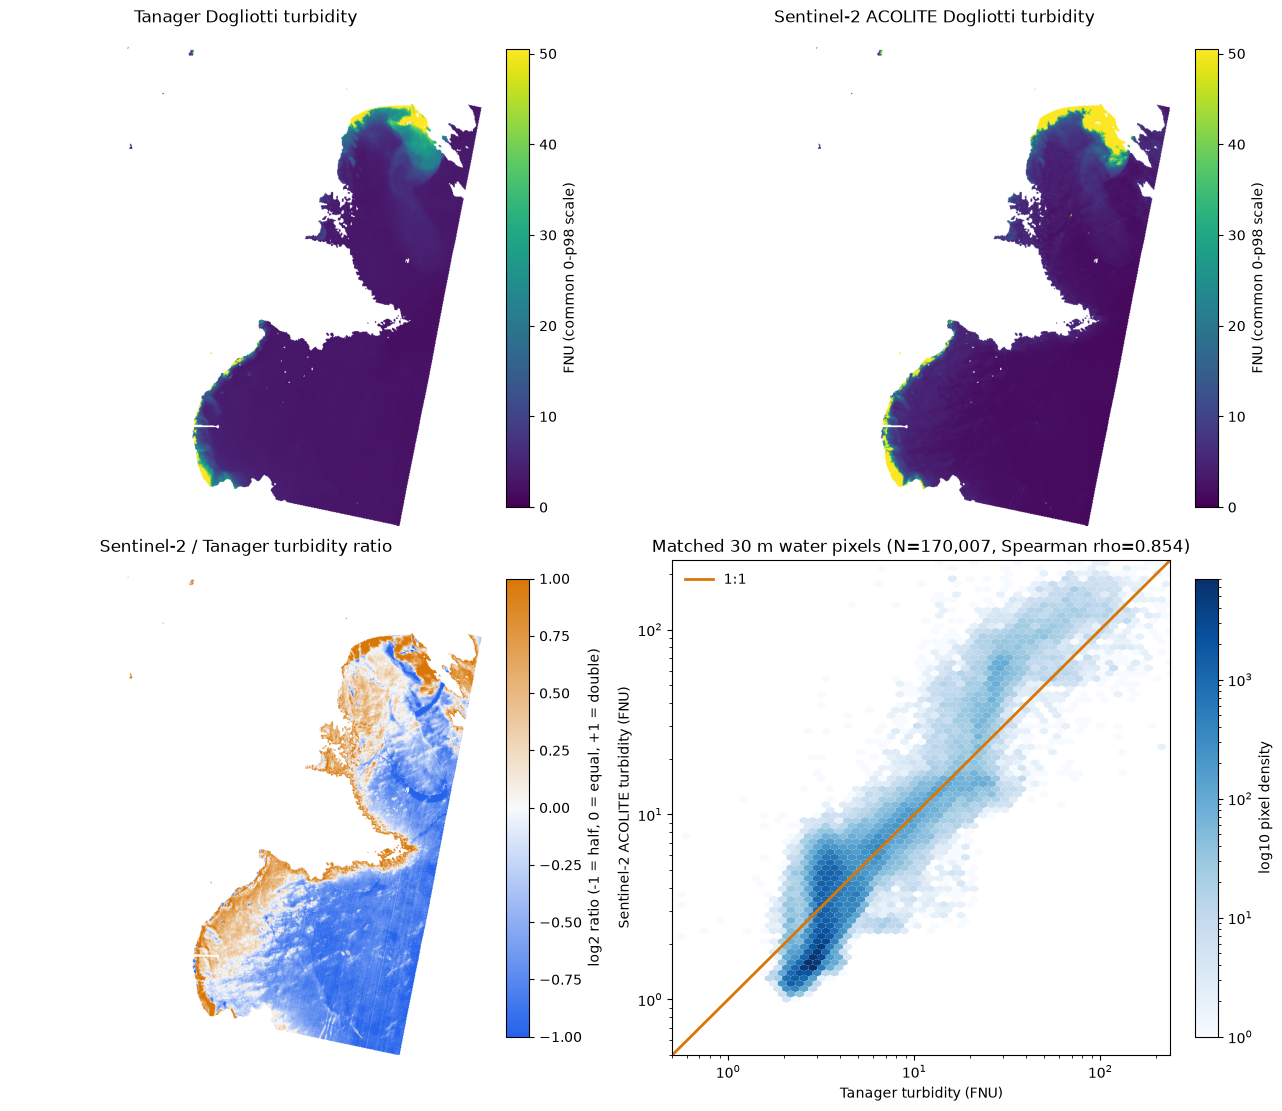

Saved: data/acolite/sangatta_s2c_20250302/s2_tanager_dogliotti_comparison.png


In [5]:
plot_tanager = np.where(common_valid, tanager_turbidity, np.nan)
plot_sentinel = np.where(common_valid, sentinel_turbidity, np.nan)
common_vmax = np.percentile(np.concatenate([
    matched_tanager_values, matched_sentinel_values
]), 98)
ratio_values = np.divide(
    sentinel_turbidity, tanager_turbidity,
    out=np.full_like(sentinel_turbidity, np.nan),
    where=common_valid & (sentinel_turbidity > 0) & (tanager_turbidity > 0),
)
log2_ratio = np.log2(ratio_values)
ratio_cmap = LinearSegmentedColormap.from_list(
    "blue_neutral_gold", ["#2563EB", "#F8FAFC", "#D97706"]
)

fig, axes = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True)
for axis, image, title in [
    (axes[0, 0], plot_tanager, "Tanager Dogliotti turbidity"),
    (axes[0, 1], plot_sentinel, "Sentinel-2 ACOLITE Dogliotti turbidity"),
]:
    shown = axis.imshow(image, cmap="viridis", vmin=0, vmax=common_vmax)
    axis.set_title(title)
    axis.set_axis_off()
    fig.colorbar(shown, ax=axis, fraction=0.046, label="FNU (common 0-p98 scale)")

ratio_image = axes[1, 0].imshow(log2_ratio, cmap=ratio_cmap, vmin=-1, vmax=1)
axes[1, 0].set_title("Sentinel-2 / Tanager turbidity ratio")
axes[1, 0].set_axis_off()
ratio_bar = fig.colorbar(ratio_image, ax=axes[1, 0], fraction=0.046)
ratio_bar.set_label("log2 ratio (-1 = half, 0 = equal, +1 = double)")

positive = (matched_tanager_values > 0) & (matched_sentinel_values > 0)
hexplot = axes[1, 1].hexbin(
    matched_tanager_values[positive], matched_sentinel_values[positive],
    gridsize=85, xscale="log", yscale="log", bins="log", mincnt=1,
    cmap="Blues", linewidths=0,
)
limit_low = max(0.5, min(matched_tanager_values[positive].min(), matched_sentinel_values[positive].min()))
limit_high = max(np.percentile(matched_tanager_values[positive], 99.95),
                 np.percentile(matched_sentinel_values[positive], 99.95))
axes[1, 1].plot([limit_low, limit_high], [limit_low, limit_high], color="#D97706", lw=2, label="1:1")
axes[1, 1].set_xlim(limit_low, limit_high)
axes[1, 1].set_ylim(limit_low, limit_high)
axes[1, 1].set_xlabel("Tanager turbidity (FNU)")
axes[1, 1].set_ylabel("Sentinel-2 ACOLITE turbidity (FNU)")
axes[1, 1].set_title(f"Matched 30 m water pixels (N={common_valid.sum():,}, Spearman rho={rank_correlation:.3f})")
axes[1, 1].legend(frameon=False)
fig.colorbar(hexplot, ax=axes[1, 1], fraction=0.046, label="log10 pixel density")

figure_path = ACOLITE_OUT / "s2_tanager_dogliotti_comparison.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", figure_path)

## Optional AI TSS rank check

[`05_ai_water_quality.ipynb`](./05_ai_water_quality.ipynb) provides an independent sediment
estimate as TSS in g/m^3, not another FNU product. Converting TSS to FNU would require in-situ,
site-specific calibration. The valid comparison is spatial rank agreement only.


In [6]:
ai_path = TANAGER_DIR / "mdn_olci_products.npz"
if ai_path.exists():
    ai = np.load(ai_path)
    ai_tss = ai["tss"]
    ai_common = common_valid & np.isfinite(ai_tss)
    ai_tss_stats = distribution_stats(np.where(ai_common, ai_tss, np.nan))
    sentinel_tss_rank = float(spearmanr(sentinel_turbidity[ai_common], ai_tss[ai_common]).statistic)
    tanager_tss_rank = float(spearmanr(tanager_turbidity[ai_common], ai_tss[ai_common]).statistic)
    print(f"AI TSS matched p5/median/p95: {ai_tss_stats['p5']:.2f} / "
          f"{ai_tss_stats['median']:.2f} / {ai_tss_stats['p95']:.2f} g m^-3")
    print(f"Spearman Sentinel-2 FNU vs AI TSS: {sentinel_tss_rank:.3f}")
    print(f"Spearman Tanager FNU vs AI TSS:    {tanager_tss_rank:.3f}")
else:
    ai_tss_stats = None
    sentinel_tss_rank = tanager_tss_rank = None
    print("AI product not present; optional comparison skipped.")

metrics = {
    "scene_id": SCENE_ID,
    "sentinel_product": "S2C_MSIL1C_20250302T021641_N0511_R003_T50NNF_20250302T055307",
    "acolite_source_commit": acolite_commit,
    "common_valid_pixels_30m": int(common_valid.sum()),
    "tanager_all": tanager_all,
    "sentinel_native": sentinel_all_native,
    "tanager_matched": tanager_matched,
    "sentinel_matched": sentinel_matched,
    "spearman_matched": rank_correlation,
    "pearson_log1p_matched": log_correlation,
    "within_factor_2": within_factor_2,
    "within_factor_3": within_factor_3,
    "tanager_mostly_nir_pct": tanager_mostly_nir_pct,
    "ai_tss_matched": ai_tss_stats,
    "spearman_sentinel_fnu_vs_ai_tss": sentinel_tss_rank,
    "spearman_tanager_fnu_vs_ai_tss": tanager_tss_rank,
}
metrics_path = ACOLITE_OUT / "comparison_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print("Saved:", metrics_path)

AI TSS matched p5/median/p95: 2.92 / 3.86 / 18.37 g m^-3
Spearman Sentinel-2 FNU vs AI TSS: 0.598
Spearman Tanager FNU vs AI TSS:    0.797
Saved: data/acolite/sangatta_s2c_20250302/comparison_metrics.json


## Takeaways

1. **Cross-validation supports the result with caveats.** Common-pixel p95 values agree to about
   1% (19.52 vs 19.32 FNU), spatial rank agreement is strong (rho = 0.854), and 94.6% of pixels
   are within a factor of two.
2. **Tanager has a modest clear-water positive offset.** Its matched median is 3.19 FNU versus
   Sentinel-2's 2.47 FNU. Different atmospheric-correction methods plausibly explain this
   absolute-scale uncertainty.
3. **Do not use the maximum as the headline.** Tanager's 544 FNU maximum represents a few pixels;
   use median, p95, spatial patterns, and matched-pixel agreement instead.
4. **Notebook 04 NIR-switch statistic.** It is 5.50% of valid water (11,489/208,720).
   The FNU map is unchanged.
5. **AI TSS is supportive, not an FNU validator.** Its spatial association with both FNU products
   is useful, but its g/m^3 scale remains separate without field calibration.

Overall confidence: **share with caveats**. The independent same-day sensor supports the plume
and its tens-of-FNU upper distribution. Exact clear-water values and extreme maxima remain
sensitive to atmospheric correction, adjacency, masks, and resolution.
